In [ ]:
import numpy as jnp
import matplotlib.pyplot as plt

## Spectral method 
x_lb = 0 
x_rb = 1
d = 2
n = 5
N_x =2**n


In [ ]:
def f(x, y) : 
    return jnp.cos(2*jnp.pi *x) * jnp.sin(-4*jnp.pi * y )

In [11]:
def spectral_eigenvalues(N, L=1.0):
    """Eigenvalues of the 1D derivative operator with periodic condition."""
    k = jnp.fft.fftfreq(N, d=L/N) * 2j * jnp.pi  # frequency vector
    return k  

In [12]:

"""Constructs the 1D DFT matrix of size N."""
dfmtx = jnp.fft.fft(jnp.eye(N_x))#/jnp.sqrt(N_x)

"""Constructs the 2D DFT matrix of size N x N as a Kronecker product."""
FG = jnp.kron(dfmtx, dfmtx)
GF = jnp.kron(
    (jnp.conj(dfmtx).T)/N_x, 
    (jnp.conj(dfmtx).T)/N_x, 
)

In [13]:
# classical 
    
def solver_Helmoltz(f,k): 
    f_values = f(xs, ys)

    f_h = jnp.fft.fft2(f_values)
    wave = jnp.fft.fftfreq(N_x, d= dx) * 2j* jnp.pi
    wave_real = jnp.fft.fftfreq(N_y, d= dx)* 2j* jnp.pi
    k_x, k_y = jnp.meshgrid(wave, wave_real, indexing='ij')
    denom = (k_x**2 + k_x * k_y + k_y * k_x + k_y**2) + k**2
    u_h = f_h/denom

    return jnp.fft.ifft2(u_h, s= (N_x, N_y))

# Kron
def solver_Helmoltz_FG(f,k): 

    # Fourier transform
    f_flatten = f(xs, ys).flatten()
    f_h = FG @ f_flatten

    # Build laplacian in spectral domain
    D = jnp.diag( 
        spectral_eigenvalues(N_x)
    )
    
    Elliptic_spec = jnp.kron(D**2, jnp.eye(N_x)) +  jnp.kron(D, D) + jnp.kron(D, D) +jnp.kron(jnp.eye(N_x), D**2)
    Elliptic_spec += jnp.eye(N_x * N_y) * k**2
    inverse_Elliptic = jnp.linalg.inv(Elliptic_spec)
    # Apply Laplacian in spectral domain and Inverse FFT
    u_flatten = GF @ inverse_Elliptic @ f_h

    return u_flatten.reshape(N_x, N_x)

In [14]:
import numpy as np
from scipy.linalg import sqrtm, dft
from qiskit import QuantumCircuit, transpile
from qiskit.circuit.library import QFT
from qiskit_aer import AerSimulator
def make_unitary(A):
    N = A.shape[0]
    sqrt_term = sqrtm(np.eye(N) - A.conj().T @ A)
    return np.block([
        [A,         sqrt_term],
        [sqrt_term, -A       ]
    ])




def build_helmoltz_inverse(N, k):

    D   = np.diag(spectral_eigenvalues(N))
    I   = np.eye(N)

    Elliptic_spec = (
        np.kron(D**2, I)
        + np.kron(D,    D)
        + np.kron(D,    D)
        + np.kron(I,    D**2)
    )
    Elliptic_spec+=jnp.eye(N * N) * k**2
    return np.linalg.inv(Elliptic_spec)


# ── Quantum circuit ────────────────────────────────────────────────────────────

def build_elliptic_circuit(inverse_Elliptic, n):

    total_qubits = 2 * n + 1
    # Normalise so that A / alpha has spectral norm ≤ 1
    alpha    = np.linalg.norm(inverse_Elliptic)
    A_normed = inverse_Elliptic / alpha

    U = make_unitary(A_normed)
  
    qft  = QFT(n)
    qft1 = QFT(n)

    qc = QuantumCircuit(total_qubits)
    qc.append(qft,          list(range(n)))
    qc.append(qft1,         list(range(n, 2 * n)))
    qc.unitary(U,           list(range(total_qubits)))
    qc.append(qft.inverse(),  list(range(n)))
    qc.append(qft1.inverse(), list(range(n, 2 * n)))

    return qc, alpha


def extract_unitary(qc):
    """Simulates the circuit and returns its full unitary matrix."""
    print("  Simulating unitary...")
    qc_sim = qc.copy()
    qc_sim.save_unitary()
    sim    = AerSimulator(method="unitary")
    qc_sim = transpile(qc_sim, sim)
    result = sim.run(qc_sim).result()
    return np.array(result.get_unitary(qc_sim))



In [15]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.ticker as ticker

def plot_solutions_and_errors(N, xs, ys, u_theo, u_spec, u_quantum, label='', save_path=None):
    """
    2x3 panel:
      top row    – Reference | Classical (FG) | Quantum
      bottom row – (blank)   | Classical err  | Quantum err
    """
    u_theo_r    = np.array(u_theo).real
    u_spec_r    = np.array(u_spec).real
    u_quantum_r = np.array(u_quantum).real

    err_FG = np.abs(u_spec_r    - u_theo_r)
    err_QC = np.abs(u_quantum_r - u_theo_r)

    vmin_u = min(u_theo_r.min(), u_spec_r.min(), u_quantum_r.min())
    vmax_u = max(u_theo_r.max(), u_spec_r.max(), u_quantum_r.max())
    vmax_e = max(err_FG.max(), err_QC.max()) or 1.0
    ext    = [xs.min(), xs.max(), ys.min(), ys.max()]

    kw_sol = dict(origin='lower', vmin=vmin_u, vmax=vmax_u,
                  extent=ext, cmap='viridis', aspect='equal')
    kw_err = dict(origin='lower', vmin=0, vmax=vmax_e,
                  extent=ext, cmap='viridis', aspect='equal')

    fig = plt.figure(figsize=(14, 7))
    gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.3, wspace=0.2)

    # ── Row 1: solutions ─────────────────────────────────────────────
    titles_row1 = ['Reference', 'Classical (FG)', 'Quantum']
    sols = [u_theo_r, u_spec_r, u_quantum_r]
    for col in range(3):
        ax = fig.add_subplot(gs[0, col])
        im = ax.imshow(sols[col].T, **kw_sol)
        ax.set_title(titles_row1[col], fontsize=11)
        ax.set_xticks([]); ax.set_yticks([])
        if col == 2:
            divider = make_axes_locatable(ax)
            cax = divider.append_axes("right", size="5%", pad=0.1)
            cb  = fig.colorbar(im, cax=cax, format='%.2f')
            cb.ax.tick_params(labelsize=8)

    # ── Row 2: errors ────────────────────────────────────────────────
    fig.add_subplot(gs[1, 0]).axis('off')
    titles_row2 = ['Classical error', 'Quantum error']
    errs = [err_FG, err_QC]
    for i, col in enumerate(range(1, 3)):
        ax = fig.add_subplot(gs[1, col])
        im = ax.imshow(errs[i].T, **kw_err)
        ax.set_title(titles_row2[i], fontsize=11)
        ax.set_xticks([]); ax.set_yticks([])
        if col == 2:
            divider   = make_axes_locatable(ax)
            cax       = divider.append_axes("right", size="5%", pad=0.1)
            formatter = ticker.ScalarFormatter(useMathText=True)
            formatter.set_scientific(True)
            formatter.set_powerlimits((0, 0))
            cb = fig.colorbar(im, cax=cax, format=formatter)
            cb.ax.tick_params(labelsize=8)
            cb.ax.yaxis.get_offset_text().set_fontsize(9)

    if label:
        fig.suptitle(f'A = {label}', fontsize=13, y=1.01)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=100, bbox_inches='tight')
    plt.show()



  Configuration : k_1
  k value       : 1 (k^2 = 1)

  Building inverse operator with k^2 = 1...

  Running classical solver...
  Classical error: 5.761715e-15

  Building quantum circuit...


C:\Users\giaco\AppData\Local\Temp\ipykernel_41976\2178783239.py:43: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qft  = QFT(n)
C:\Users\giaco\AppData\Local\Temp\ipykernel_41976\2178783239.py:44: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qft1 = QFT(n)


  Simulating unitary...

  Computing quantum solution...
  Quantum error:   1.536474e-14

  ───────────────────────────────────────────
  Classical error : 5.761715e-15
  Quantum error   : 1.536474e-14


C:\Users\giaco\AppData\Local\Temp\ipykernel_41976\2635416318.py:69: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


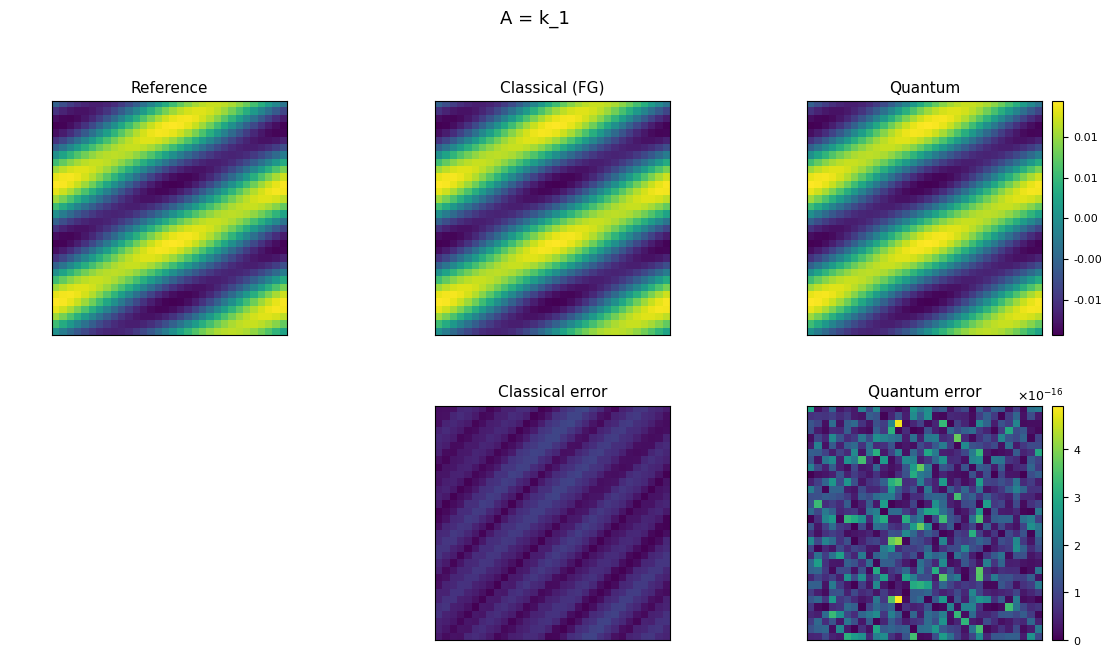


  Figure saved : results_helmoltz_configs\k_1_solutions_errors.png
  Info JSON saved: results_helmoltz_configs\k_1_info.json

  Configuration : k_2
  k value       : 2 (k^2 = 4)

  Building inverse operator with k^2 = 4...

  Running classical solver...
  Classical error: 1.120626e-15

  Building quantum circuit...
  Simulating unitary...

  Computing quantum solution...
  Quantum error:   2.120156e-15

  ───────────────────────────────────────────
  Classical error : 1.120626e-15
  Quantum error   : 2.120156e-15


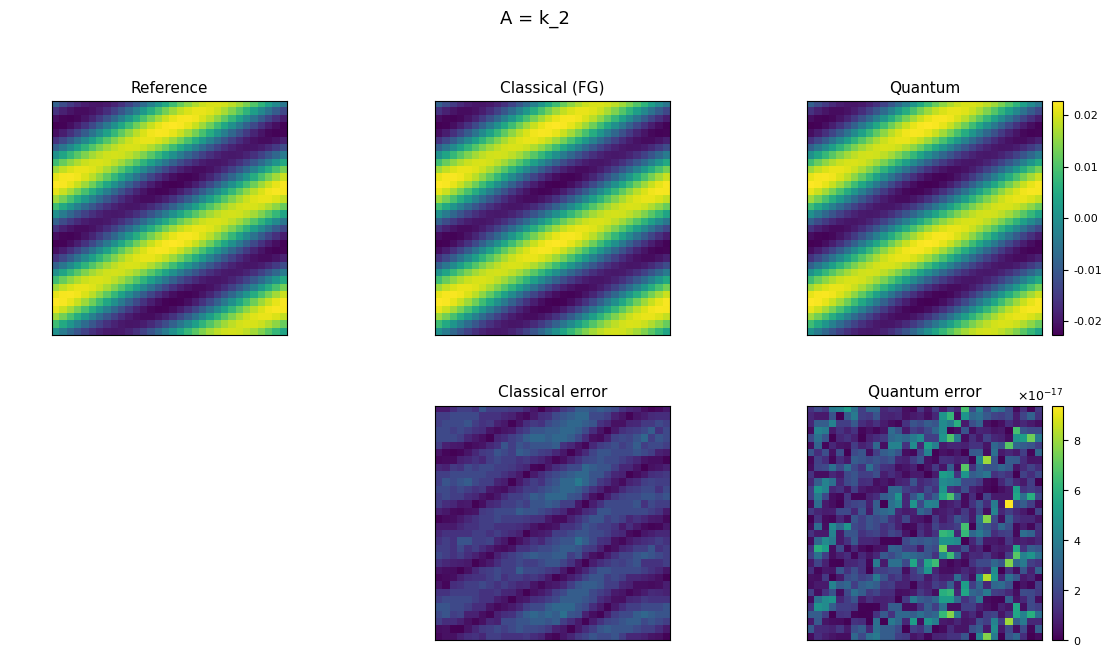


  Figure saved : results_helmoltz_configs\k_2_solutions_errors.png
  Info JSON saved: results_helmoltz_configs\k_2_info.json

  Configuration : k_5
  k value       : 5 (k^2 = 25)

  Building inverse operator with k^2 = 25...

  Running classical solver...
  Classical error: 5.254989e-15

  Building quantum circuit...
  Simulating unitary...

  Computing quantum solution...
  Quantum error:   1.426352e-14

  ───────────────────────────────────────────
  Classical error : 5.254989e-15
  Quantum error   : 1.426352e-14


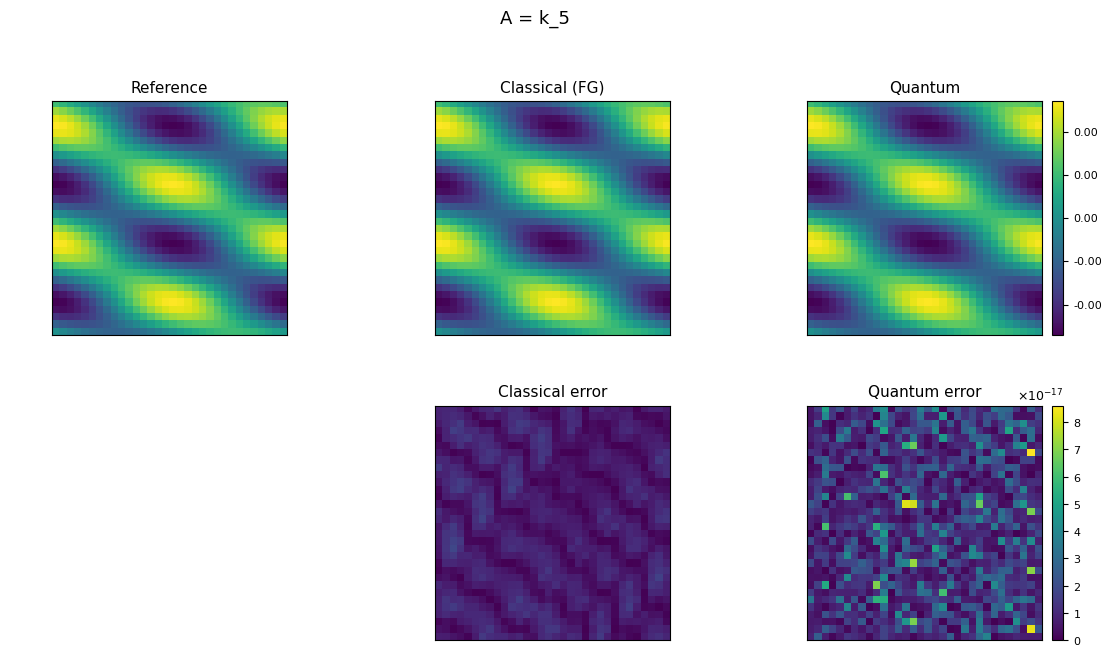


  Figure saved : results_helmoltz_configs\k_5_solutions_errors.png
  Info JSON saved: results_helmoltz_configs\k_5_info.json

  Configuration : k_10
  k value       : 10 (k^2 = 100)

  Building inverse operator with k^2 = 100...

  Running classical solver...
  Classical error: 5.415378e-15

  Building quantum circuit...
  Simulating unitary...

  Computing quantum solution...
  Quantum error:   7.237061e-15

  ───────────────────────────────────────────
  Classical error : 5.415378e-15
  Quantum error   : 7.237061e-15


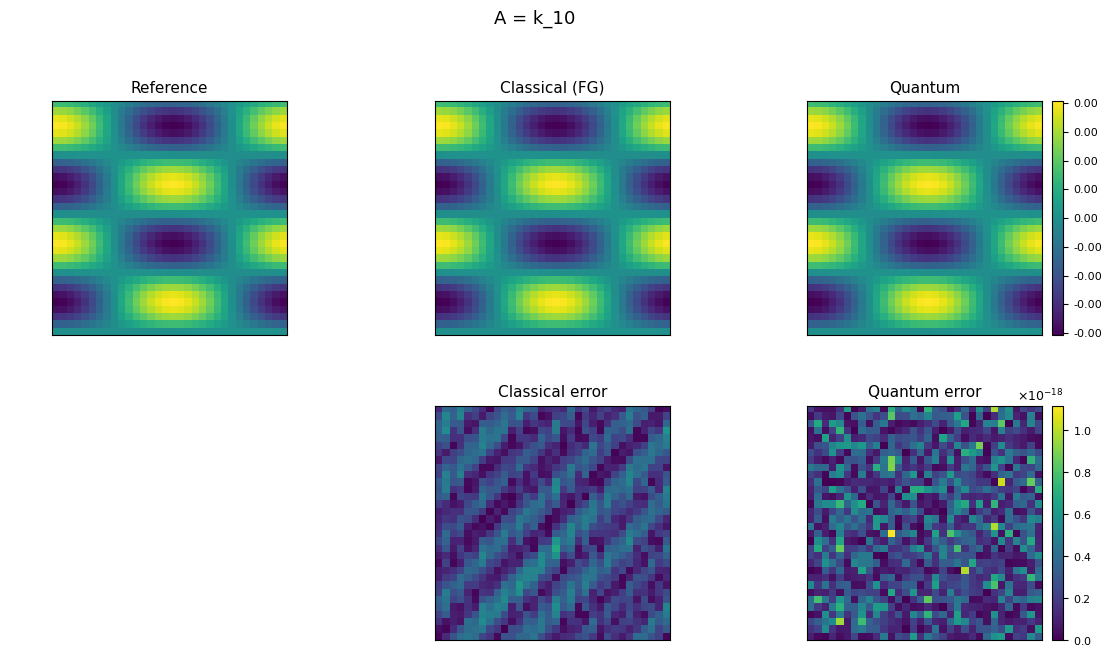


  Figure saved : results_helmoltz_configs\k_10_solutions_errors.png
  Info JSON saved: results_helmoltz_configs\k_10_info.json

  Configuration : k_20
  k value       : 20 (k^2 = 400)

  Building inverse operator with k^2 = 400...

  Running classical solver...
  Classical error: 1.298322e-15

  Building quantum circuit...
  Simulating unitary...

  Computing quantum solution...
  Quantum error:   2.363038e-15

  ───────────────────────────────────────────
  Classical error : 1.298322e-15
  Quantum error   : 2.363038e-15


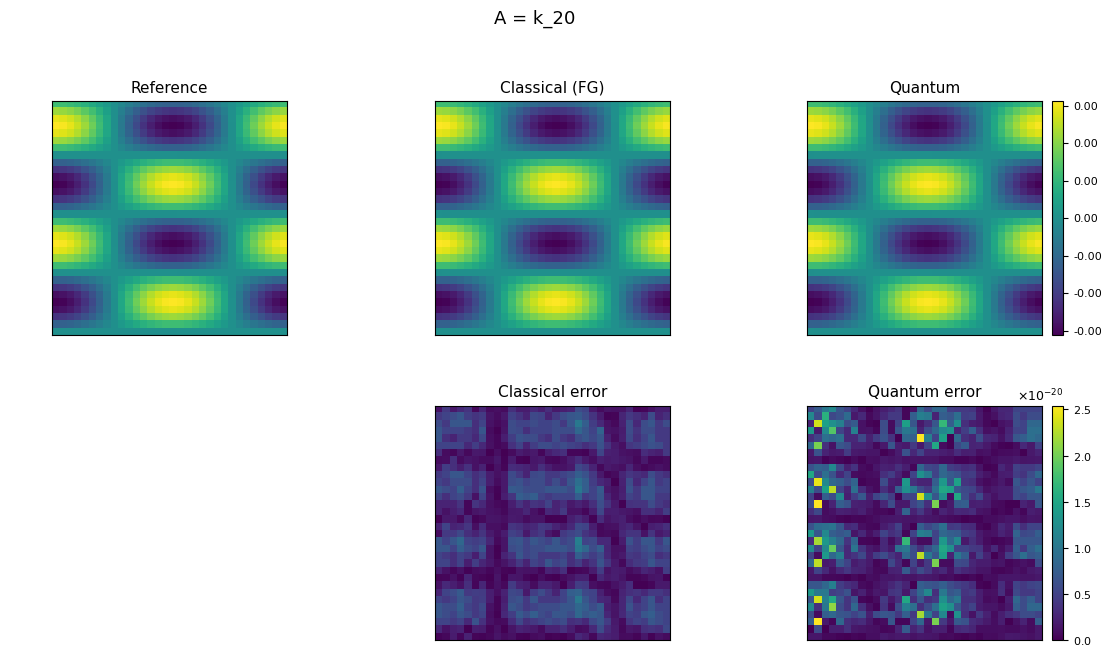


  Figure saved : results_helmoltz_configs\k_20_solutions_errors.png
  Info JSON saved: results_helmoltz_configs\k_20_info.json

  All done!  Results in: 'results_helmoltz_configs/'


In [ ]:
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt

# ── k configurations ───────────────────────────────────────────────────────────
# Updated k values as requested: [1, 1e1, 1e2, 1e3, 1e4]
k_values = [1, 10, 100, 1000, 10000]
k_configs = [{'label': f'k_{int(kv)}', 'k_val': kv} for kv in k_values]

# Output directory
out_dir = "results_helmoltz_configs"
os.makedirs(out_dir, exist_ok=True)

plt.rcParams.update({'font.size': 22})

for cfg in k_configs:
    label = cfg['label']
    k_current = cfg['k_val']
    k_sq = k_current**2  
    
    print(f"\n{'='*55}")
    print(f"   Configuration : {label}")
    print(f"   k value       : {k_current} (k^2 = {k_sq:.2e})")
    print(f"{'='*55}")

    # ── Build inverse operator ──
    print(f"\n   Building inverse operator with k^2 = {k_sq:.2e}...")
    inverse_Elliptic = build_helmoltz_inverse(N_x, k_sq)

    # ── Classical solution ──
    print("\n   Running classical solver...")
    u_spec = solver_Helmoltz_FG(f, k_sq)
    u_theo = solver_Helmoltz(f, k_sq)
    
    error_classical = float(np.linalg.norm(u_spec - u_theo) / np.linalg.norm(u_theo))

    # ── Quantum solution ──
    print("\n   Building quantum circuit and computing solution...")
    qc, alpha = build_elliptic_circuit(inverse_Elliptic, n)
    mat = extract_unitary(qc)

    block_size    = 2 ** (d * n)
    leading_block = mat[:block_size, :block_size]
    
    f_vec         = f(xs, ys).flatten()
    f_norm        = np.linalg.norm(f_vec)
    f_normalized  = f_vec / f_norm
    
    u_quantum_vec = leading_block @ (alpha * f_normalized) * f_norm
    u_quantum     = u_quantum_vec.reshape(N_x, N_x)
    
    error_quantum = float(np.linalg.norm(u_quantum - u_theo) / np.linalg.norm(u_theo))

    print(f"\n   {'─'*43}")
    print(f"   Classical error : {error_classical:.6e}")
    print(f"   Quantum error   : {error_quantum:.6e}")

    # ── [UPDATED] Save results to HDF5 file ───────────────────────────
    h5_path = os.path.join(out_dir, f"{label}_results.h5")
    with h5py.File(h5_path, 'w') as hf:
        # Datasets for arrays
        hf.create_dataset('u_theoretical', data=u_theo.real)
        hf.create_dataset('u_classical',   data=u_spec.real)
        hf.create_dataset('u_quantum',     data=u_quantum.real)
        
        # Metadata and parameters
        hf.attrs['k_value']         = k_current
        hf.attrs['error_classical'] = error_classical
        hf.attrs['error_quantum']   = error_quantum
        hf.attrs['label']           = label

    print(f"   H5 Data saved:  {h5_path}")

    # ── Save solutions / errors figure ──
    path_fig = os.path.join(out_dir, f"{label}_solutions_errors.png")
    plot_solutions_and_errors(N_x, xs, ys, u_theo, u_spec, u_quantum,
                              label=label, save_path=path_fig)
    print(f"   Figure saved : {path_fig}")

print(f"\n{'='*55}")
print(f"   All done! Results saved in: '{out_dir}/'")
print(f"{'='*55}")